# Combined Sweep: Season × Cloud Cover × Classifier

This notebook evaluates all classifiers across seasons and cloud cover thresholds to find the optimal combination.

In [1]:
import os
from dotenv import load_dotenv, find_dotenv
import ee
import geemap

# ── Constants ────────────────────────────────────────────────────────────────

CAMPUS_GEOJSON = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458, 23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ],
}

BANDS = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI", "NDBI", "SAVI"]
SEED = 42

WATER_POINTS_ASSET = "users/cosypix/multi_water_points"
FOREST_POINTS_ASSET = "users/cosypix/multi_forest_points"
SOIL_POINTS_ASSET = "users/cosypix/multi_soil_points"
BUILDINGS_POINTS_ASSET = "users/cosypix/multi_buildings_points"

CLASSIFIER_CONFIGS = {
    "cart": {"maxNodes": 10, "minLeafPopulation": 10},
    "rf": {"numberOfTrees": 200, "minLeafPopulation": 1, "bagFraction": 0.3, "maxNodes": 10},
    "knn": {"k": 5, "searchMethod": "AUTO", "metric": "EUCLIDEAN"},
    "svm": {"kernelType": "RBF", "gamma": 1.0, "cost": 100.0},
    "xgb": {"numberOfTrees": 200, "shrinkage": 0.05, "maxNodes": 5},
}

CLASSIFIER_DISPLAY_NAMES = {
    "cart": "CART",
    "rf": "Random Forest",
    "knn": "k-NN",
    "svm": "SVM (RBF)",
    "xgb": "XGBoost",
}

def init_ee():
    """Initialize Earth Engine using EE_PROJECT_ID from the .env file."""
    load_dotenv(find_dotenv())
    ee_project = os.getenv("EE_PROJECT_ID")
    if not ee_project:
        raise ValueError("EE_PROJECT_ID not set in .env file")
    ee.Initialize(project=ee_project)
    print("Earth Engine initialized successfully.")

def get_campus_geometry():
    """Return the campus boundary as an ee.Geometry."""
    return ee.Geometry(CAMPUS_GEOJSON)

def mask_s2_clouds(image):
    """Apply Sentinel-2 QA60 cloud/cirrus mask and scale to reflectance."""
    qa = image.select("QA60")
    cloud = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

def build_image(roi, start_date, end_date, cloud_cover=5):
    """Build a cloud-masked Sentinel-2 median composite clipped to *roi*, with spectral indices appended."""
    dataset = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_cover))
        .map(mask_s2_clouds)
    )

    image = dataset.median().clip(roi)
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    ndbi = image.normalizedDifference(["B11", "B8"]).rename("NDBI")
    savi = image.expression(
        "1.5 * (NIR - RED) / (NIR + RED + 0.5)",
        {"NIR": image.select("B8"), "RED": image.select("B4")}
    ).rename("SAVI")
    image = image.addBands([ndvi, ndwi, ndbi, savi])
    return image

def load_training_points():
    """Load and merge multi-class training point FeatureCollections."""
    water = ee.FeatureCollection(WATER_POINTS_ASSET)
    forest = ee.FeatureCollection(FOREST_POINTS_ASSET)
    soil = ee.FeatureCollection(SOIL_POINTS_ASSET)
    buildings = ee.FeatureCollection(BUILDINGS_POINTS_ASSET)
    training_points = water.merge(forest).merge(soil).merge(buildings)
    return water, forest, soil, buildings, training_points

def sample_and_split(image, training_points, bands=None, seed=None, split=0.7):
    """Sample *image* at *training_points* and split into train/test sets."""
    if bands is None:
        bands = BANDS
    if seed is None:
        seed = SEED

    training = image.select(bands).sampleRegions(
        collection=training_points,
        properties=["label"],
        scale=10,
    )
    training = training.filter(ee.Filter.notNull(bands + ["label"]))
    training = training.randomColumn("random", seed)

    train_set = training.filter(ee.Filter.lt("random", split))
    test_set = training.filter(ee.Filter.gte("random", split))
    return train_set, test_set

def create_classifier(model_type):
    """Return an **untrained** ee.Classifier with canonical hyperparameters."""
    if model_type not in CLASSIFIER_CONFIGS:
        raise ValueError(f"Unknown model_type '{model_type}'. Choose from {list(CLASSIFIER_CONFIGS.keys())}")
    params = CLASSIFIER_CONFIGS[model_type]
    if model_type == "cart":
        return ee.Classifier.smileCart(**params)
    elif model_type == "rf":
        return ee.Classifier.smileRandomForest(**params)
    elif model_type == "knn":
        return ee.Classifier.smileKNN(**params)
    elif model_type == "svm":
        return ee.Classifier.libsvm(**params)
    elif model_type == "xgb":
        return ee.Classifier.smileGradientTreeBoost(**params)

def get_classifier_factories():
    return {
        CLASSIFIER_DISPLAY_NAMES[key]: (lambda k=key: create_classifier(k))
        for key in CLASSIFIER_CONFIGS
    }

def train_model(
    model_type,
    start_date="2026-01-01",
    end_date="2026-02-28",
    cloud_cover=5,
    bands=None,
    seed=None,
    split=0.7,
):
    """Complete training pipeline: build image → sample → split → train."""
    if bands is None:
        bands = BANDS
    if seed is None:
        seed = SEED

    campus = get_campus_geometry()
    image = build_image(campus, start_date, end_date, cloud_cover)

    *_, training_points = load_training_points()
    train_set, test_set = sample_and_split(
        image, training_points, bands=bands, seed=seed, split=split
    )

    classifier = create_classifier(model_type).train(
        features=train_set,
        classProperty="label",
        inputProperties=bands,
    )

    return classifier, train_set, test_set



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

init_ee()


Earth Engine initialized successfully.


### Campus Boundary

In [3]:
campus = get_campus_geometry()


### Cloud Mask & Helpers

In [4]:
bands = BANDS


### Load Training Points

In [5]:
water_points, forest_points, soil_points, buildings_points, training_points = load_training_points()

print(f"Water points:     {water_points.size().getInfo()}")
print(f"Forest points:    {forest_points.size().getInfo()}")
print(f"Soil points:      {soil_points.size().getInfo()}")
print(f"Buildings points: {buildings_points.size().getInfo()}")


Water points:     128
Forest points:    150
Soil points:      150
Buildings points: 150


### Define Seasons & Classifiers

In [6]:
SEASONS = {
    "Early Summer":  ("2025-03-01", "2025-04-30"),
    "Post-Monsoon":  ("2025-09-01", "2025-10-31"),
    "Winter":         ("2025-11-01", "2025-12-31"),
}

CLOUD_COVER_VALUES = [5, 10, 15, 20, 30, 50]
CLASSIFIERS = get_classifier_factories()

print(f"Seasons:     {list(SEASONS.keys())}")
print(f"Classifiers: {list(CLASSIFIERS.keys())}")
print(f"Cloud Cover: {CLOUD_COVER_VALUES}%")


Seasons:     ['Early Summer', 'Post-Monsoon', 'Winter']
Classifiers: ['CART', 'Random Forest', 'k-NN', 'SVM (RBF)', 'XGBoost']
Cloud Cover: [5, 10, 15, 20, 30, 50]%


### Run Season × Classifier Sweep

In [7]:
results = []

for season_name, (start_date, end_date) in SEASONS.items():
    for cc in CLOUD_COVER_VALUES:
        print(f"{'='*60}")
        print(f"  Season: {season_name} | Cloud Cover: {cc}%")
        print(f"{'='*60}")

        # Build the median composite
        dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                   .filterDate(start_date, end_date)
                   .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cc))
                   .map(mask_s2_clouds))

        img_count = dataset.size().getInfo()
        print(f"  Available images: {img_count}")

        if img_count == 0:
            print(f"  ⚠ No images – skipping")
            for clf_name in CLASSIFIERS:
                results.append({
                    'season': season_name, 'cloud_cover': cc, 'classifier': clf_name,
                    'accuracy': None, 'kappa': None, 'image_count': 0,
                })
            continue

        image = dataset.median().clip(campus)

        # Add spectral indices
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
        ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
        savi = image.expression(
            '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
            {'NIR': image.select('B8'), 'RED': image.select('B4')}
        ).rename('SAVI')
        image = image.addBands([ndvi, ndwi, ndbi, savi])

        # Sample and split 
        train_set, test_set = sample_and_split(image, training_points, bands)

        for clf_name, clf_factory in CLASSIFIERS.items():
            try:
                classifier = clf_factory().train(
                    features=train_set,
                    classProperty='label',
                    inputProperties=bands
                )

                validated = test_set.classify(classifier)
                cm = validated.errorMatrix('label', 'classification')
                accuracy = cm.accuracy().getInfo()
                kappa = cm.kappa().getInfo()
                cm_array = cm.getInfo()

                print(f"  {clf_name:25s}  Accuracy: {accuracy:.4f}   Kappa: {kappa:.4f}")

                results.append({
                    'season': season_name,
                    'cloud_cover': cc,
                    'classifier': clf_name,
                    'accuracy': accuracy,
                    'kappa': kappa,
                    'confusion_matrix': str(cm_array),
                    'image_count': img_count,
                })
            except Exception as e:
                print(f"  {clf_name:25s}  ERROR: {e}")
                results.append({
                    'season': season_name, 'cloud_cover': cc, 'classifier': clf_name,
                    'accuracy': None, 'kappa': None, 'image_count': img_count,
                })

print("✅ Sweep complete!")


  Season: Early Summer | Cloud Cover: 5%
  Available images: 159886
  CART                       Accuracy: 0.9467   Kappa: 0.9284
  Random Forest              Accuracy: 0.9467   Kappa: 0.9284
  k-NN                       Accuracy: 0.9290   Kappa: 0.9045
  SVM (RBF)                  Accuracy: 0.9408   Kappa: 0.9204
  XGBoost                    Accuracy: 0.9408   Kappa: 0.9284
  Season: Early Summer | Cloud Cover: 10%
  Available images: 204562
  CART                       Accuracy: 0.9432   Kappa: 0.9241
  Random Forest              Accuracy: 0.9432   Kappa: 0.9241
  k-NN                       Accuracy: 0.9545   Kappa: 0.9392
  SVM (RBF)                  Accuracy: 0.9716   Kappa: 0.9620
  XGBoost                    Accuracy: 0.9659   Kappa: 0.9544
  Season: Early Summer | Cloud Cover: 15%
  Available images: 240530
  CART                       Accuracy: 0.9412   Kappa: 0.9212
  Random Forest              Accuracy: 0.9519   Kappa: 0.9355
  k-NN                       Accuracy: 0.9626   Ka

### Results Table

In [8]:
df = pd.DataFrame(results)
print(df[['season', 'cloud_cover', 'classifier', 'accuracy', 'kappa']].to_string(index=False))
df.to_csv('combined_comparison_results.csv', index=False)
print('\nSaved results to combined_comparison_results.csv')


      season  cloud_cover    classifier  accuracy    kappa
Early Summer            5          CART  0.946746 0.928420
Early Summer            5 Random Forest  0.946746 0.928407
Early Summer            5          k-NN  0.928994 0.904488
Early Summer            5     SVM (RBF)  0.940828 0.920429
Early Summer            5       XGBoost  0.940828 0.928380
Early Summer           10          CART  0.943182 0.924105
Early Summer           10 Random Forest  0.943182 0.924086
Early Summer           10          k-NN  0.954545 0.939237
Early Summer           10     SVM (RBF)  0.971591 0.962028
Early Summer           10       XGBoost  0.965909 0.954445
Early Summer           15          CART  0.941176 0.921197
Early Summer           15 Random Forest  0.951872 0.935502
Early Summer           15          k-NN  0.962567 0.949876
Early Summer           15     SVM (RBF)  0.973262 0.964197
Early Summer           15       XGBoost  0.962567 0.949876
Early Summer           20          CART  0.903955 0.8716

### Overall Best Configuration

In [9]:
print("="*60)
print("  🏆 OVERALL BEST CONFIGURATION 🏆")
print("="*60)
valid_df = df.dropna(subset=['accuracy'])
if not valid_df.empty:
    best = valid_df.loc[valid_df['accuracy'].idxmax()]
    print(f"Best Season:      {best['season']}")
    print(f"Best Cloud Cover: {best['cloud_cover']}%")
    print(f"Best Classifier:  {best['classifier']}")
    print(f"Accuracy:         {best['accuracy']:.4f}")
    print(f"Kappa:            {best['kappa']:.4f}")
else:
    print("No valid results to display.")


  🏆 OVERALL BEST CONFIGURATION 🏆
Best Season:      Winter
Best Cloud Cover: 15%
Best Classifier:  XGBoost
Accuracy:         0.9745
Kappa:            0.9524


=== Top 3 Results per Model ===

CART


,season,cloud_cover,accuracy,kappa
0,Winter,30,0.954802,0.939513
1,Early Summer,5,0.946746,0.928420
2,Early Summer,10,0.943182,0.924105
3,Early Summer,15,0.941176,0.921197
4,Early Summer,50,0.931818,0.908824




Random Forest


,season,cloud_cover,accuracy,kappa
0,Early Summer,15,0.951872,0.935502
1,Early Summer,50,0.948864,0.931577
2,Early Summer,5,0.946746,0.928407
3,Early Summer,10,0.943182,0.924086
4,Post-Monsoon,5,0.941520,0.921603




k-NN


,season,cloud_cover,accuracy,kappa
0,Early Summer,15,0.962567,0.949876
1,Early Summer,50,0.960227,0.946704
2,Early Summer,10,0.954545,0.939237
3,Winter,50,0.946524,0.928604
4,Early Summer,20,0.943503,0.924436




SVM (RBF)


,season,cloud_cover,accuracy,kappa
0,Early Summer,15,0.973262,0.964197
1,Early Summer,10,0.971591,0.962028
2,Early Summer,20,0.960452,0.947051
3,Winter,15,0.959184,0.945593
4,Winter,30,0.954802,0.939529




XGBoost


,season,cloud_cover,accuracy,kappa
0,Winter,15,0.974490,0.952379
1,Winter,50,0.973262,0.964310
2,Early Summer,10,0.965909,0.954445
3,Early Summer,50,0.965909,0.954325
4,Early Summer,15,0.962567,0.949876


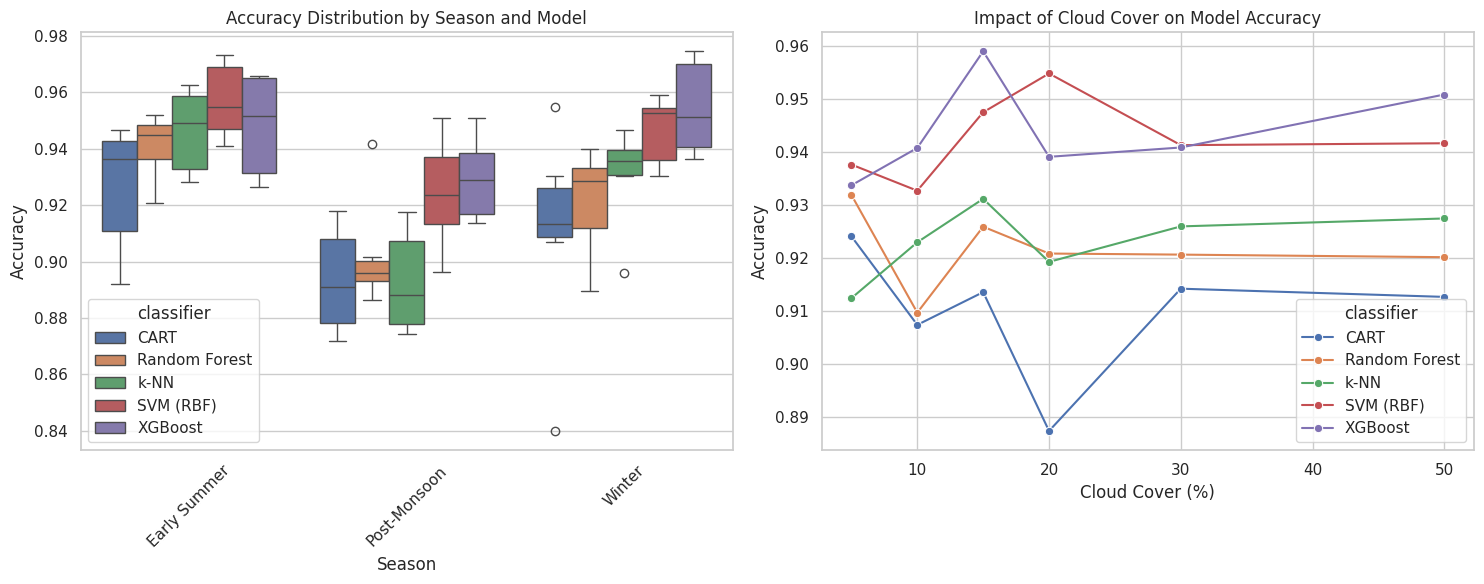

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the combined results
df = pd.read_csv('combined_comparison_results.csv')

# Filter out 100% accuracy results as they are likely anomalies
df_filtered = df[df['accuracy'] < 0.9999]

print("=== Top 3 Results per Model ===\n")
for clf in df_filtered['classifier'].unique():
    subset = df_filtered[df_filtered['classifier'] == clf]
    top3 = subset.sort_values(by=['accuracy', 'kappa'], ascending=[False, False]).head(5)
    
    print(f"\033[1m{clf}\033[0m")
    display(top3[['season', 'cloud_cover', 'accuracy', 'kappa']].reset_index(drop=True))
    print("\n")

# --- Visualizations ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy Distribution among Seasons
sns.boxplot(data=df_filtered, x='season', y='accuracy', hue='classifier', ax=axes[0])
axes[0].set_title('Accuracy Distribution by Season and Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Season')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Impact of Cloud Cover on Accuracy
try:
    sns.lineplot(data=df_filtered, x='cloud_cover', y='accuracy', hue='classifier', marker='o', errorbar=None, ax=axes[1])
except TypeError:
    # Fallback for older seaborn versions
    sns.lineplot(data=df_filtered, x='cloud_cover', y='accuracy', hue='classifier', marker='o', ci=None, ax=axes[1])

axes[1].set_title('Impact of Cloud Cover on Model Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Cloud Cover (%)')

plt.tight_layout()
plt.show()


In [11]:
# Group by season and cloud_cover to find the average score across all models
intersection_scores = df_filtered.groupby(['season', 'cloud_cover']).agg(
    avg_accuracy=('accuracy', 'mean'),
    avg_kappa=('kappa', 'mean'),
    model_count=('classifier', 'nunique') # Count unique models per combination
).reset_index()

# Ensure we're only looking at combinations where all 3 models were evaluated
max_models = intersection_scores['model_count'].max()
intersection_scores = intersection_scores[intersection_scores['model_count'] == max_models]

# Retrieve the combination with the highest average accuracy
best_intersection = intersection_scores.sort_values(by=['avg_accuracy', 'avg_kappa'], ascending=[False, False]).iloc[0]

print("=== Best Overall (Intersection) Condition ===")
print(f"Season:       {best_intersection['season']}")
print(f"Cloud Cover:  {best_intersection['cloud_cover']}%")
print(f"Average Acc:  {best_intersection['avg_accuracy']:.4f}")
print(f"Average Kap:  {best_intersection['avg_kappa']:.4f}\n")

# Show how each individual model performed under these exact winning conditions
print("=== Individual Model Performances on this Condition ===")
winning_subset = df_filtered[
    (df_filtered['season'] == best_intersection['season']) & 
    (df_filtered['cloud_cover'] == best_intersection['cloud_cover'])
]
display(winning_subset[['classifier', 'accuracy', 'kappa']].reset_index(drop=True))


=== Best Overall (Intersection) Condition ===
Season:       Early Summer
Cloud Cover:  15%
Average Acc:  0.9583
Average Kap:  0.9441

=== Individual Model Performances on this Condition ===


,classifier,accuracy,kappa
0,CART,0.941176,0.921197
1,Random Forest,0.951872,0.935502
2,k-NN,0.962567,0.949876
3,SVM (RBF),0.973262,0.964197
4,XGBoost,0.962567,0.949876
